In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import glob
import re

import matplotlib.cm as cm
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=cm.Dark2.colors)

In [39]:
path = "../files/data/Aug2025"

pressure = 5

# nexus      = pd.read_hdf(f"{path}/Leptoquark_1bar_nexus_175.h5", "MC/hits")
nexus      = pd.read_hdf(f"{path}/Leptoquark_{pressure}bar_nexus_175.h5", "MC/hits")
parts      = pd.read_hdf(f"{path}/Leptoquark_{pressure}bar_nexus_175.h5", "MC/particles")

print(nexus.event_id.unique())

[14080 14081 14082 14083 14084 14085 14086 14087 14088 14089 14090 14091
 14092 14093 14094 14095 14096 14097 14098 14099 14100 14101 14102 14103
 14104 14105 14106 14107 14108 14109 14110 14111 14112 14113 14114 14115
 14116 14117 14118 14119 14120 14121 14122 14123 14124 14125 14126 14127
 14128 14129 14130 14131 14132 14133 14134 14135 14136 14137 14138 14139
 14140 14141 14142 14143 14144 14145 14146 14147 14148 14149 14150 14151
 14152 14153 14154]


### Plot the true information

In [40]:
density = 5.987*pressure
M = 1000/0.9
det_size = 1000*np.cbrt((4 * M) / (np.pi * density))/2.0

# This shifts the z pos of the events so 0 is at anode
# can set this to zero
z_shift = det_size

/var/folders/cf/0fb79lcx5z9by5185swm__x00000gr/T/ipykernel_2734/195249511.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Plot1DEvent(131, ev_nexus.x, ev_nexus.y, "x", "y", vtx[0], vtx[1])
/var/folders/cf/0fb79lcx5z9by5185swm__x00000gr/T/ipykernel_2734/195249511.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Plot1DEvent(132, ev_nexus.x, ev_nexus.z, "x", "z", vtx[0], vtx[2])
/var/folders/cf/0fb79lcx5z9by5185swm__x00000gr/T/ipykernel_2734/195249511.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent 

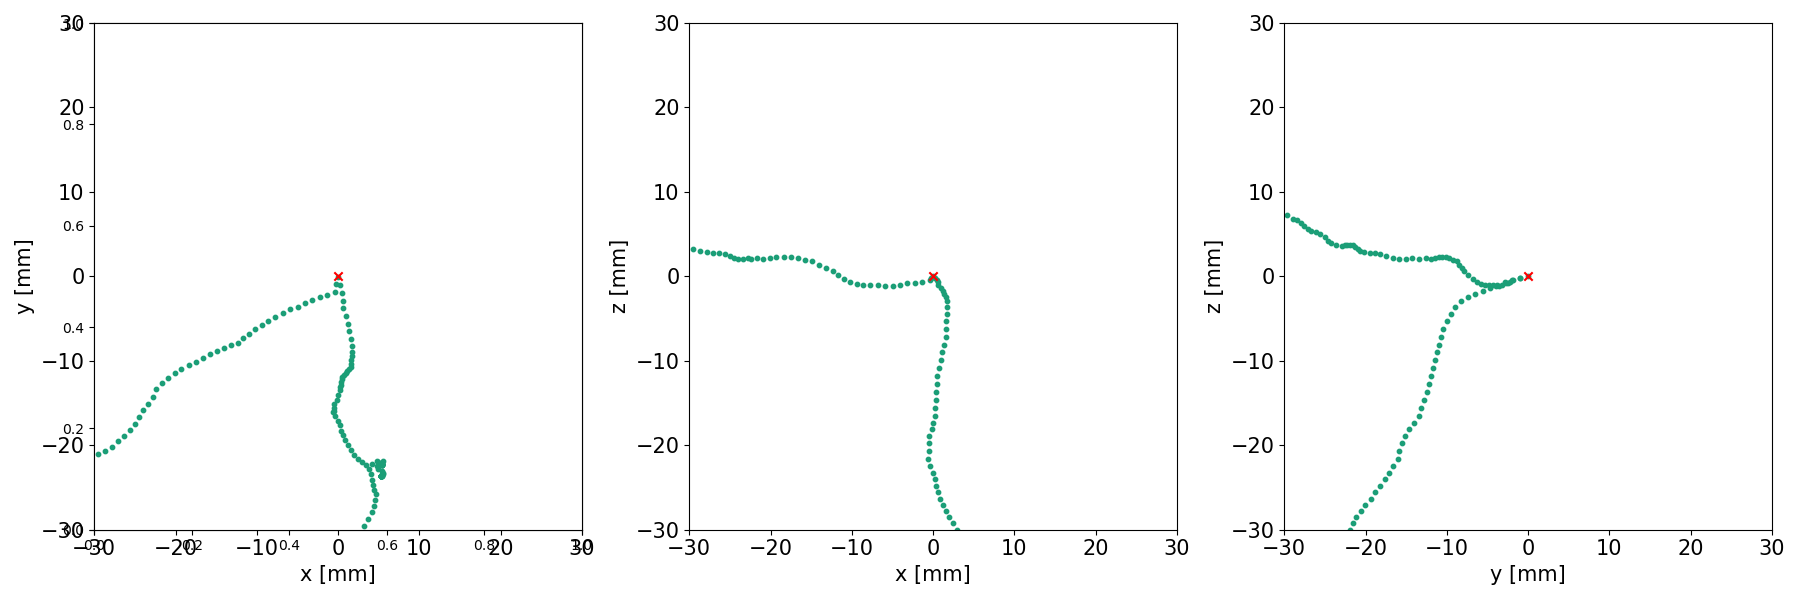

In [ ]:
%matplotlib widget
# plt.figure()

ev_id = 14080

ev_nexus = nexus[nexus.event_id == ev_id]
ev_parts = parts[parts.event_id == ev_id]
vtx = ev_parts[ev_parts.particle_id == 1][["initial_x", "initial_y", "initial_z"]].iloc[0]

def Plot1DEvent(axis, x, y, x_label, y_label, vtx_x, vtx_y):
    ax = fig.add_subplot(axis)

    fig.set_facecolor('white')
    ax.set_facecolor('white')
    ax.scatter(x, y, s=10, label = "nexus")
    ax.set_xlabel(f"{x_label} [mm]", fontsize = 15)
    ax.set_ylabel(f"{y_label} [mm]", fontsize = 15)
    plt.tick_params(axis='both', which='both', labelsize=15)  # Adjust labelsize as needed
    ax.scatter(vtx_x,vtx_y, color="r", marker="x")
    ax.set_xlim(-30,30)
    ax.set_ylim(-30,30)


fig  = plt.figure(figsize=(18, 6))

ax = fig.add_subplot(131)
Plot1DEvent(131, ev_nexus.x, ev_nexus.y, "x", "y", vtx[0], vtx[1])
Plot1DEvent(132, ev_nexus.x, ev_nexus.z, "x", "z", vtx[0], vtx[2])
Plot1DEvent(133, ev_nexus.y, ev_nexus.z, "y", "z", vtx[1], vtx[2])

fig.tight_layout()


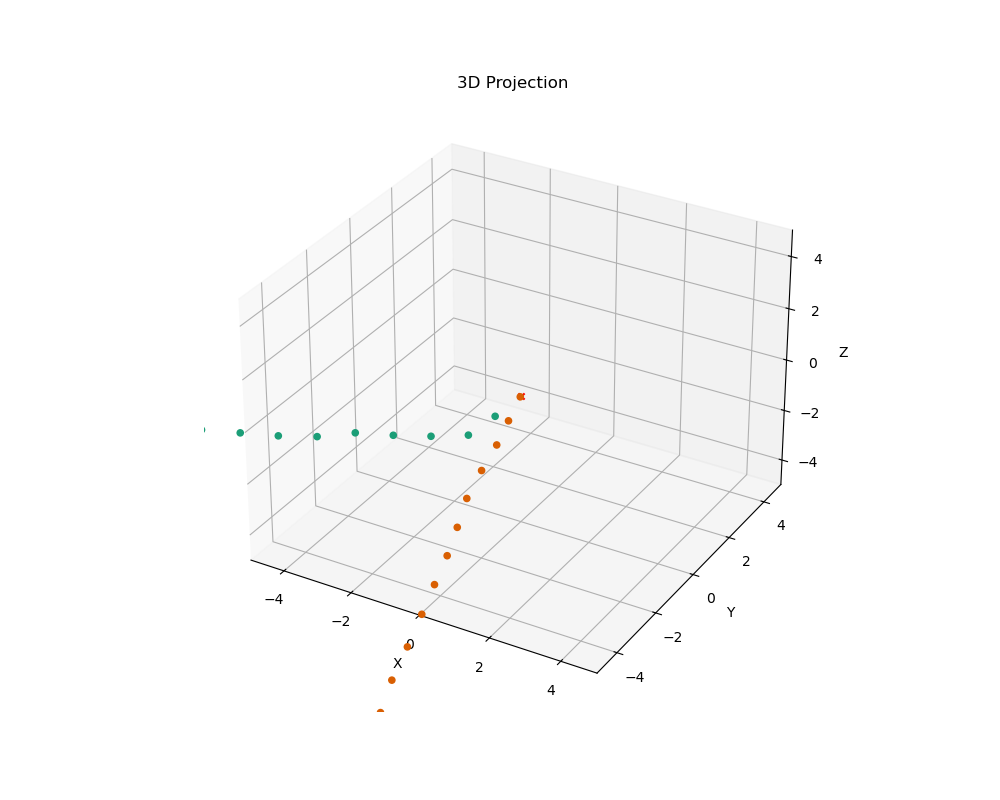

/var/folders/cf/0fb79lcx5z9by5185swm__x00000gr/T/ipykernel_2734/1346608227.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


In [ ]:
# Plot the event
# Plot in 3D
fig = plt.figure(figsize=(10, 8))
ax2 = fig.add_subplot(111, projection='3d')

part_1 = ev_nexus[ev_nexus.particle_id == 1]
part_2 = ev_nexus[ev_nexus.particle_id == 2]

ax2.scatter(0,0,0, marker='x',color="r")

ax2.scatter(part_1['x'], part_1['y'], part_1['z'], marker='o',alpha=1)
ax2.scatter(part_2['x'], part_2['y'], part_2['z'], marker='o',alpha=1)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title('3D Projection')
ax2.set_xlim(-5,5)
ax2.set_ylim(-5,5)
ax2.set_zlim(-5,5)
plt.show()
plt.legend()

### Now lets plot an example diffused sample

In [11]:
diffused      = pd.read_hdf(f"{path}/Leptoquark_5bar_5.0percent_smear_175.h5", "MC/hits")

/var/folders/cf/0fb79lcx5z9by5185swm__x00000gr/T/ipykernel_2734/88070876.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ev_diff["z"]= ev_diff["z"]-z_shift
/var/folders/cf/0fb79lcx5z9by5185swm__x00000gr/T/ipykernel_2734/88070876.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Plot1DEvent(131, ev_diff.x, ev_diff.y, "x", "y", vtx[0], vtx[1])
/var/folders/cf/0fb79lcx5z9by5185swm__x00000gr/T/ipykernel_2734/88070876.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as la

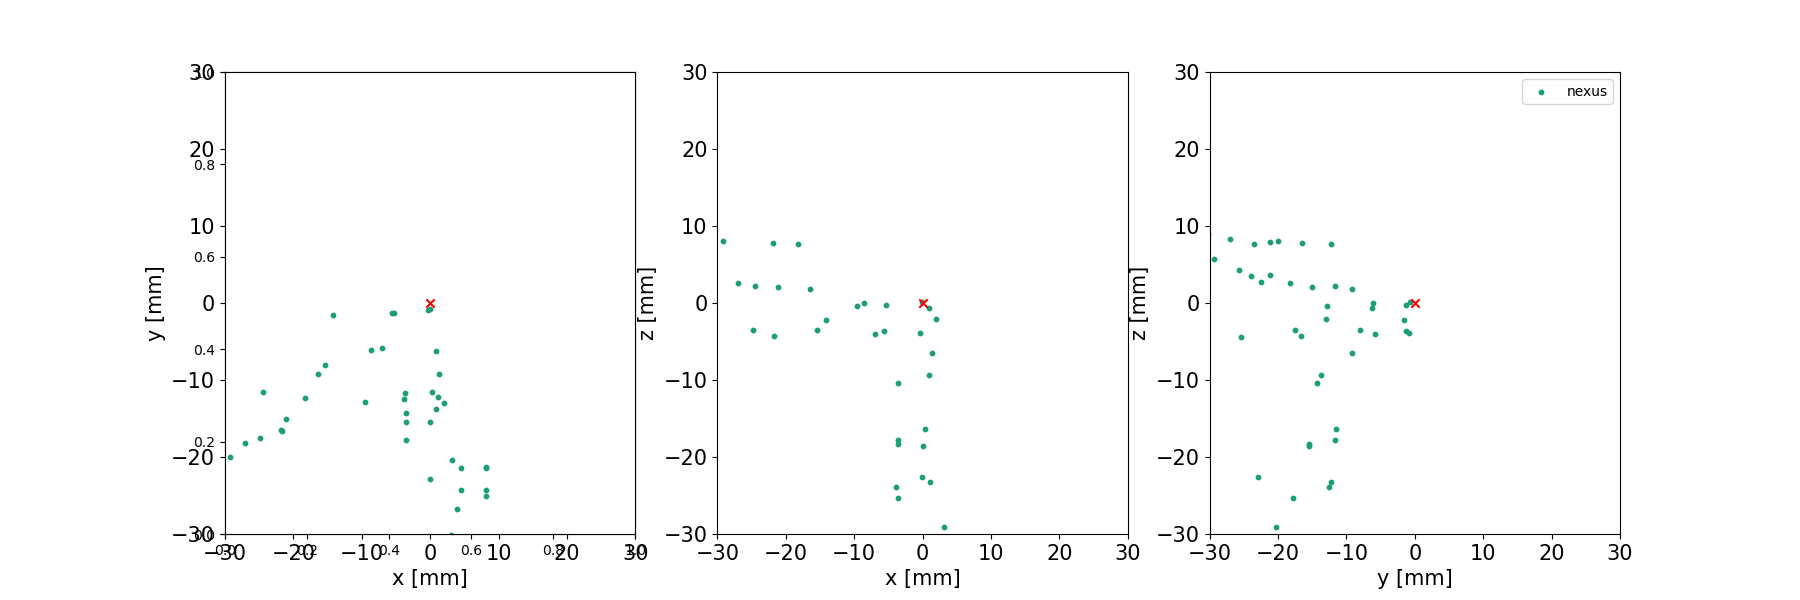

In [44]:
%matplotlib widget

ev_diff = diffused[diffused.event_id == 14080]
ev_diff["z"]= ev_diff["z"]-z_shift

fig  = plt.figure(figsize=(18, 6))

ax = fig.add_subplot(131)
Plot1DEvent(131, ev_diff.x, ev_diff.y, "x", "y", vtx[0], vtx[1])
Plot1DEvent(132, ev_diff.x, ev_diff.z, "x", "z", vtx[0], vtx[2])
Plot1DEvent(133, ev_diff.y, ev_diff.z, "y", "z", vtx[1], vtx[2])

plt.legend()
